In [ ]:
import sys
sys.path.append("../src")
from data_loader import (load_prices, compute_hedge_ratio, 
                          compute_spread, compute_zscore)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

prices = load_prices()
train_prices = prices["2018-01-01":"2021-12-31"]
test_prices  = prices["2022-01-01":"2023-12-31"]

ml_dataset = pd.read_csv("../data/ml_dataset_ranked.csv")
print("Loaded dataset shape:", ml_dataset.shape)
print(ml_dataset[["ticker_1","ticker_2","test_sharpe"]].head())

Loaded dataset shape: (21, 21)
  ticker_1 ticker_2  test_sharpe
0     META      TGT      -1.3989
1       MA      WMT       0.3046
2        V      WMT       0.1832
3    GOOGL      UNH       0.6794
4      JNJ      TGT      -0.2039


In [ ]:
def mean_crossing(spread):
    """count how many times spread crosses its mean"""

    mean = spread.mean()
    above = spread > mean
    crossings = (above != above.shift(1)).sum()
    return int(crossings)

def rolling_corr_stability(prices , t1 , t2 , w1 = 60 , w2 = 120):
    """Difference between 60-day and 120-day rollong correlation"""

    corr_60 = prices[t1].rolling(w1).corr(prices[t2]).mean()
    corr_120 = prices[t2].rolling(w2).corr(prices[t2]).mean()
    return round(abs(corr_60-corr_120),4)

def  spread_kurtosis(spread):
    return round(spread.kurtosis(),4)

def recent_coint_stability(prices,t1,t2,n,windows = 3):
    """
    Run cointegeration on last n sub-windows.
    Returns fraction of windows where pair is cointegrated.
    """

    from statsmodels.tsa.stattools import coint
    n = len(prices) // n_windows
    count = 0 
    for i in range(n_windows):
        chunk = prices.iloc[i*n : (i+1)*n]
        try : 
            _,pval , _ = coint(chunk[t1] , chunk[t2])
            if pval < 0.05:
                count+=1
        except:
            pass
    return round(count/n_windows,4)

# compute new features for all pairs
new_features = []
for _ , row in ml_dataset.iterrows():
    t1 , t2 = row["ticker_1" ], row["ticker_2"]
    try :
        beta,intercept = compute_hedge_ratio(train_prices,t1,t2)
        spread = compute_spread(train_prices , t1,t2,beta, intercept)

        mc = mean_crossing(spread)
        rcs = rolling_corr_stability(train_prices , t1 ,t2)
        kurt = spread_kurtosis(spread)
        rcs2 = recent_coint_stability(train_prices , t1, t2)

        new_features.append({
            "ticker_1" : t1 , "ticker_2": t2,
            "mean_crossings": mc,
            "corr_stability": rcs,
            "spread_kurtosis": kurt,
            "coint_stability": rcs2
        })
        print(f"Done: {t1}/{t2}")
    
    except Exception as e : 
        new_features.append({
        "ticker_1" : t1 , "ticker_2" : t2 , 
        "mean_crossing" : 0 , 
        "corr_stability" : 0 , 
        "spread_kurtosis" : 0 ,
        "coint_stability" : 0
        })

new_feat_df = pd.DataFrame(new_features)
ml_expanded = ml_dataset.merge(new_feat_df , on = ["ticker_1" , "ticker_2"])
print("\nExpanded dataset shape:", ml_expanded.shape)
print("New features added:", ["mean_crossings","corr_stability","spread_kurtosis","coint_stability"])


Expanded dataset shape: (21, 25)
New features added: ['mean_crossings', 'corr_stability', 'spread_kurtosis', 'coint_stability']


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

feature_cols = ["coint_pval" , "correlation" , "spread_std" , "half_life" , "hurst" , "spread_skew" , "beta_stability" , "mean_crossing" , "corr_stability" , "spread_kurtosis" , "coint_stability"]

X = ml_expanded[feature_cols].copy()
X = X.replace([np.inf , -np.inf] , np.nan)
X = X.fillna(X.median())

y = ml_expanded["test_sharpe"].copy()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X),columns = feature_cols)

print("Feature matrix shape:" , X_scaled.shape)
print("Target (test sharpe) stats:")
print(f"  Mean: {y.mean():.3f} Std : {y.std():.3f}")
print(f"  Min : {y.min():.3f}  Max: {y.max():.3f}")

Feature matrix shape: (21, 11)
Target (test sharpe) stats:
  Mean: -0.083 Std : 0.825
  Min : -1.731  Max: 1.321


In [ ]:
# Train XGBoost and compare with RF
from xgboost import XGBRegressor 
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits = 5 , shuffle = True , random_state=42)

# RF Regressor 
rf = RandomForestRegressor(n_estimators=100 , max_depth=3 , min_samples_leaf =2 , random_state =42)
rf_cv = cross_val_score(rf,X_scaled,y,cv=cv , scoring = "r2")

# XGBoost 
xgb = XGBRegressor(n_estimators = 100 , learning_rate = 0.05 , max_depth = 3 , random_state = 42 , verbosity = 0)

xgb_cv= cross_val_score(xgb , X_scaled , y , cv=cv,scoring = "r2")

print("Cross-validation R² scores:")
print(f"  RF  scores : {rf_cv.round(3)}")
print(f"  RF  mean   : {rf_cv.mean():.3f} ± {rf_cv.std():.3f}")
print()
print(f"  XGB scores : {xgb_cv.round(3)}")
print(f"  XGB mean   : {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")

Cross-validation R² scores:
  RF  scores : [-0.242 -0.848  0.146 -0.657 -1.021]
  RF  mean   : -0.524 ± 0.424

  XGB scores : [-0.026 -0.272 -0.342 -1.161 -1.52 ]
  XGB mean   : -0.664 ± 0.574


In [ ]:
#  Train both on full dataset, get rankings
rf.fit(X_scaled , y)
xgb.fit(X_scaled , y)

ml_expanded["rf_score"] = rf.predict(X_scaled)
ml_expanded["xgb_score"] = xgb.predict(X_scaled)
print(ml_expanded.columns.tolist())
# ranking comparison
def top_n_sharpe(df,score_col,n=5):
    return round(df.nlargest(n,score_col)["test_sharpe"].mean(),4)

# p-value baseline
ml_expanded["pval_rank_score"] = -ml_expanded["coint_pval"]

print("Average test Sharpe = Top 5 pairs by method:")
print(f"  P-value baseline : {top_n_sharpe(ml_expanded, 'pval_rank_score')}")
print(f"  RF Regressor     : {top_n_sharpe(ml_expanded , 'rf_score')}")
print(f"  XGBoost          : {top_n_sharpe(ml_expanded,'xgb_score')}")

print("\n To p5 XGBoost ranked pairs:")
print(ml_expanded.nlargest(5,"xgb_score")[["ticker_1" , "ticker_2" , "xgb_score" , "test_sharpe"]].to_string())

['ticker_1', 'ticker_2', 'coint_pval', 'correlation', 'spread_std', 'half_life', 'hurst', 'adf_pval', 'spread_skew', 'beta_stability', 'test_sharpe', 'test_return', 'label', 'rf_score', 'rf_predicted', 'rf_predicted_sharpe', 'pval_rank', 'hurst_rank', 'train_sharpe', 'train_sharpe_rank', 'rf_rank', 'mean_crossing', 'corr_stability', 'spread_kurtosis', 'coint_stability', 'xgb_score']
Average test Sharpe = Top 5 pairs by method:
  P-value baseline : -0.0871
  RF Regressor     : 0.8979
  XGBoost          : 0.8979

 To p5 XGBoost ranked pairs:
   ticker_1 ticker_2  xgb_score  test_sharpe
18      ABT       CL   1.135250       1.3207
17       MA        V   0.903872       0.9809
5       ABT      JNJ   0.786662       0.9742
3     GOOGL      UNH   0.653629       0.6794
15      CAT       DE   0.550475       0.5344


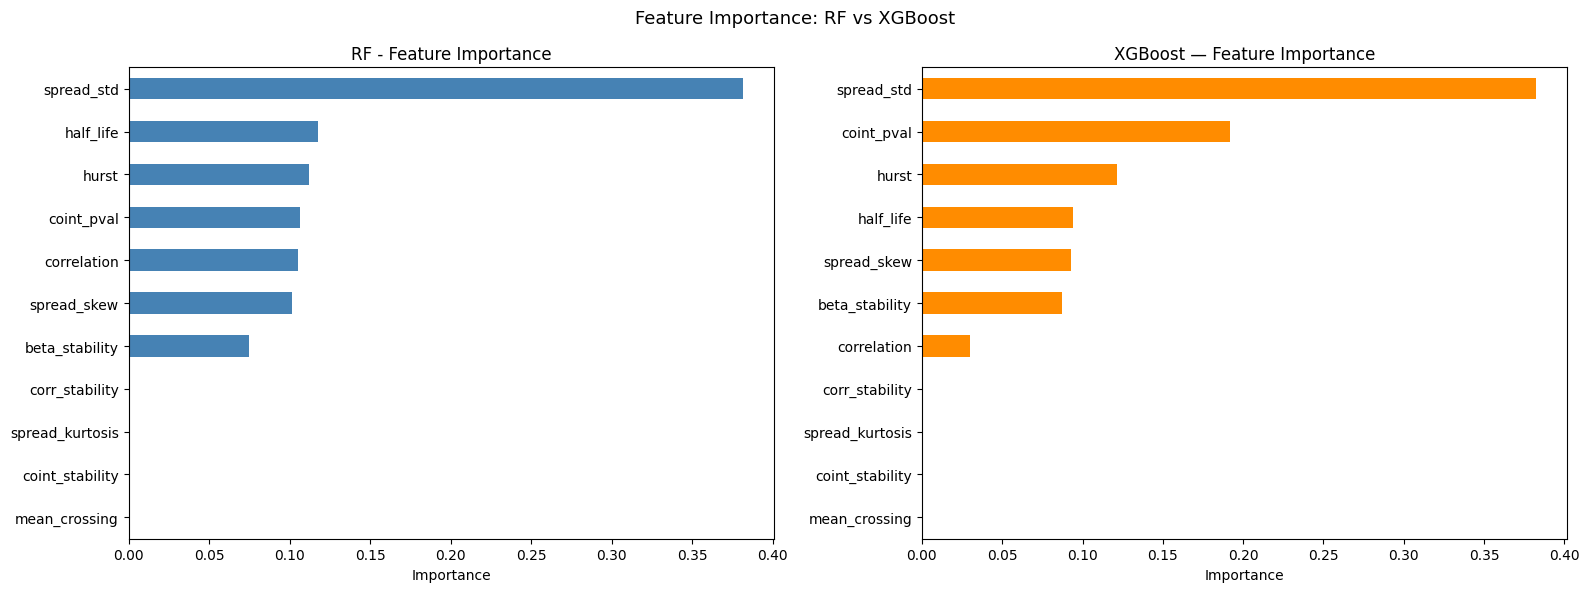

RF top feature  : spread_std
XGB top feature : spread_std


In [ ]:
fig , axes = plt.subplots(1,2,figsize= (16,6))

# RF importance 
rf_imp = pd.Series(rf.feature_importances_ , index = feature_cols).sort_values(ascending=True)
rf_imp.plot(kind = "barh" ,ax =axes[0] ,color = "steelblue")
axes[0].set_title("RF - Feature Importance")
axes[0].set_xlabel("Importance")

# XGB importance
xgb_imp = pd.Series(xgb.feature_importances_ , index = feature_cols).sort_values(ascending=True)
xgb_imp.plot(kind="barh" , ax = axes[1] , color="darkorange")
axes[1].set_title("XGBoost — Feature Importance")
axes[1].set_xlabel("Importance")

plt.suptitle("Feature Importance: RF vs XGBoost", fontsize=13)
plt.tight_layout()
plt.savefig("../data/feature_importance_comparison.png", dpi=120)
plt.show()

print("RF top feature  :" , rf_imp.idxmax())
print("XGB top feature :", xgb_imp.idxmax())

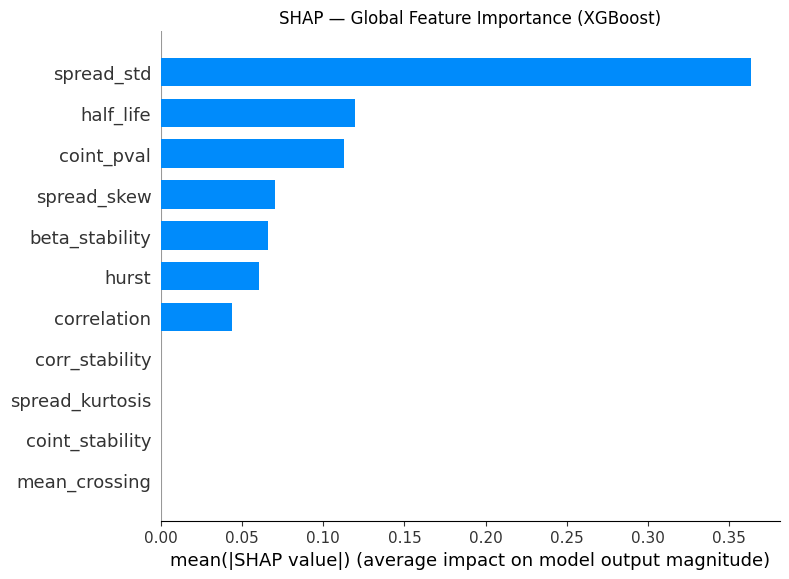


Explaining best pair: ABT / CL
Predicted Sharpe :1.135
Actual Sharpe    :1.321


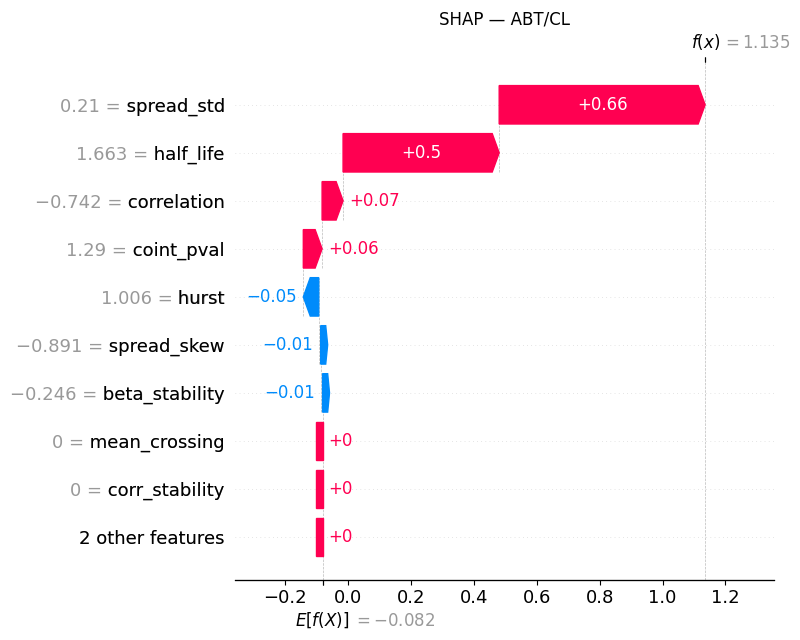

In [ ]:
#  SHAP Analysis 
import shap 

# SHAP for XGBoost 
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_scaled)

# global feature importance 
fig , ax = plt.subplots(figsize=(10,6))
shap.summary_plot(shap_values , X_scaled , plot_type = "bar" , show = False)
plt.title("SHAP — Global Feature Importance (XGBoost)")
plt.tight_layout()
plt.savefig("../data/shap_global.png", dpi=120, bbox_inches="tight")
plt.show()

# explain best pair individually 
best_idx = ml_expanded["xgb_score"].idxmax()
best_pair = ml_expanded.iloc[best_idx]
print(f"\nExplaining best pair: {best_pair['ticker_1']} / {best_pair['ticker_2']}")
print(f"Predicted Sharpe :{best_pair['xgb_score']:.3f}")
print(f"Actual Sharpe    :{best_pair['test_sharpe']:.3f}")

shap.waterfall_plot(shap.Explanation(values = shap_values[best_idx] , base_values=explainer.expected_value , data=X_scaled.iloc[best_idx],feature_names=feature_cols),show=False)

plt.title(f"SHAP — {best_pair['ticker_1']}/{best_pair['ticker_2']}")
plt.tight_layout()
plt.savefig("../data/shap_best_pair.png", dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
import pickle

with open("../data/xgb_model.pkl" , "wb") as f:
    pickle.dump(xgb,f)

with open("../data/rf_model_v2.pkl" , "wb") as f:
    pickle.dump(rf,f)

with open("../data/scaler_v2.pkl" , "wb") as f:
    pickle.dump(scaler,f)

ml_expanded.to_csv("../data/ml_dataset_final.csv" , index = False)

print("All models saved.")
print("\nFinal dataset shape:" , ml_expanded.shape)
print("Columns:" , ml_expanded.columns.tolist())

All models saved.

Final dataset shape: (21, 27)
Columns: ['ticker_1', 'ticker_2', 'coint_pval', 'correlation', 'spread_std', 'half_life', 'hurst', 'adf_pval', 'spread_skew', 'beta_stability', 'test_sharpe', 'test_return', 'label', 'rf_score', 'rf_predicted', 'rf_predicted_sharpe', 'pval_rank', 'hurst_rank', 'train_sharpe', 'train_sharpe_rank', 'rf_rank', 'mean_crossing', 'corr_stability', 'spread_kurtosis', 'coint_stability', 'xgb_score', 'pval_rank_score']


In [ ]:
xgb_imp = pd.Series(xgb.feature_importances_, 
                     index=feature_cols).sort_values(ascending=False)
print(xgb_imp)

spread_std         0.382661
coint_pval         0.191772
hurst              0.121529
half_life          0.093789
spread_skew        0.093005
beta_stability     0.087215
correlation        0.030029
mean_crossing      0.000000
corr_stability     0.000000
spread_kurtosis    0.000000
coint_stability    0.000000
dtype: float32
